In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("sample_data/rainfall.csv")

# Display first 5 rows
df.head()

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy


# Q1. Display the first 10 rows

In [2]:
df.head(10)

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy
5,2022-01-06,15.3,16.5,75.0,7.8,Rainy
6,2022-01-07,6.8,19.2,61.0,4.5,Rainy
7,2022-01-08,0.0,21.7,48.0,2.9,Sunny
8,2022-01-09,11.2,17.3,73.0,6.1,Rainy
9,2022-01-10,18.6,15.8,79.0,8.9,Rainy


# Q2. Find the number of rows and columns

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 54
Columns: 6


# Q3. Print all column names

In [5]:
print(df.columns)

Index(['date', 'rainfall', 'temperature', 'humidity', 'wind_speed',
       'weather_condition'],
      dtype='object')


# Q4. Check data types

In [4]:
print(df.dtypes)

date                  object
rainfall             float64
temperature          float64
humidity             float64
wind_speed           float64
weather_condition     object
dtype: object


# Q5. Find missing values

In [3]:
print(df.isnull().sum())

date                 0
rainfall             1
temperature          1
humidity             1
wind_speed           1
weather_condition    1
dtype: int64


# Q6. Mean, Median and Standard Deviation of rainfall

In [7]:
print("Mean:", df["rainfall"].mean())
print("Median:", df["rainfall"].median())
print("Standard Deviation:", df["rainfall"].std())

Mean: 9.049056603773584
Median: 8.3
Standard Deviation: 6.712520524005565


# Q7. Maximum and Minimum Temperature

In [8]:
print("Maximum Temperature:", df["temperature"].max())
print("Minimum Temperature:", df["temperature"].min())

Maximum Temperature: 23.4
Minimum Temperature: 13.9


# Q8. Select numerical columns

In [9]:
num_df = df.select_dtypes(include=np.number)

print(num_df.head())

   rainfall  temperature  humidity  wind_speed
0      12.5         15.2      78.0         8.5
1       8.2         17.8      65.0         5.2
2       0.0         20.1      52.0         3.1
3       3.7         18.6      71.0         6.7
4      21.1         14.8      82.0         9.3


# Q9. Correlation Matrix

In [10]:
corr = num_df.corr()

corr

,rainfall,temperature,humidity,wind_speed
rainfall,1.000000,-0.790566,0.821357,0.733376
temperature,-0.790566,1.000000,-0.966097,-0.902996
humidity,0.821357,-0.966097,1.000000,0.951643
wind_speed,0.733376,-0.902996,0.951643,1.000000


# Q10. Heatmap

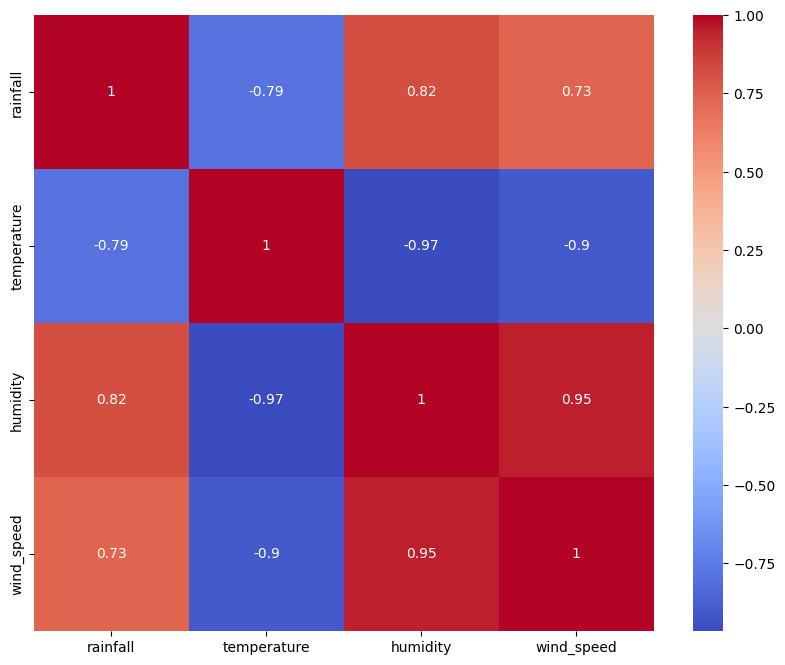

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# Q11. Correlation with rainfall

In [12]:
corr["rainfall"].sort_values(ascending=False)

,rainfall
rainfall,1.000000
humidity,0.821357
wind_speed,0.733376
temperature,-0.790566


# Q12. Feature pairs having correlation > 0.7

In [13]:
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i,j]) > 0.7:
            print(corr.columns[i], "<-->", corr.columns[j], corr.iloc[i,j])

temperature <--> rainfall -0.7905656348428082
humidity <--> rainfall 0.8213569723603099
humidity <--> temperature -0.9660971268282758
wind_speed <--> rainfall 0.7333762456183629
wind_speed <--> temperature -0.9029958088261343
wind_speed <--> humidity 0.9516425912012718


# Q13. Extract highly correlated features

In [14]:
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i,j]) > 0.7:
            high_corr.append((corr.columns[i], corr.columns[j]))

print(high_corr)

[('temperature', 'rainfall'), ('humidity', 'rainfall'), ('humidity', 'temperature'), ('wind_speed', 'rainfall'), ('wind_speed', 'temperature'), ('wind_speed', 'humidity')]


# Q14. Drop one feature from each correlated pair

In [15]:
drop_cols = set()

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i,j]) > 0.7:
            drop_cols.add(corr.columns[i])

df_new = df.drop(columns=list(drop_cols))

print(df_new.head())

         date  rainfall weather_condition
0  2022-01-01      12.5             Rainy
1  2022-01-02       8.2             Rainy
2  2022-01-03       0.0             Sunny
3  2022-01-04       3.7             Rainy
4  2022-01-05      21.1             Rainy


# Q15. Scatter plot between rainfall and humidity

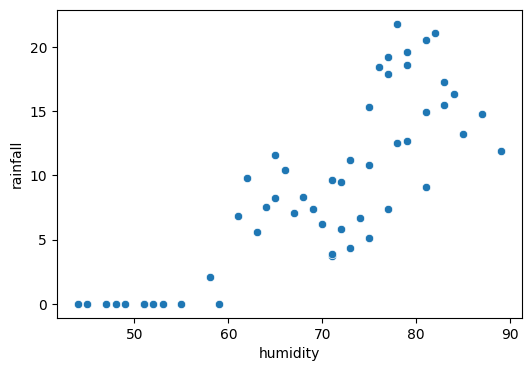

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="humidity", y="rainfall")
plt.show()

# Q16. Histograms of all numerical columns

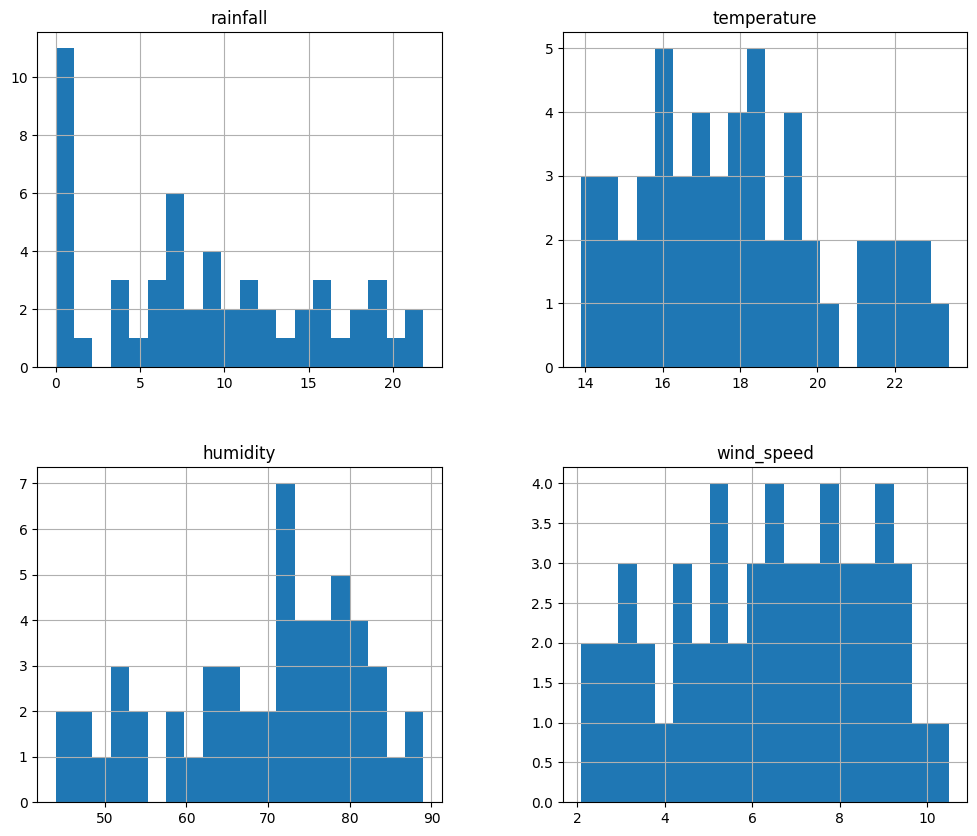

In [17]:
num_df.hist(figsize=(12,10), bins=20)
plt.show()

# Q17. Histogram of rainfall

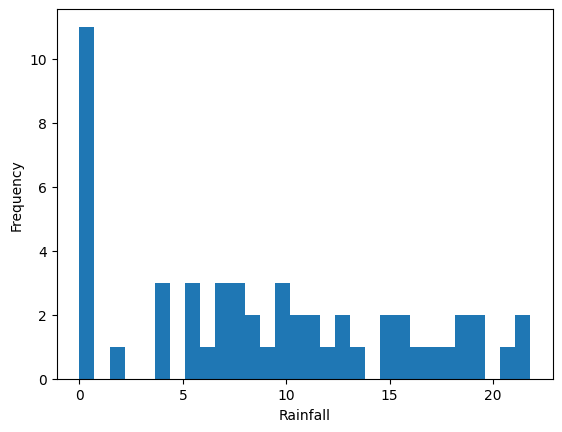

In [18]:
plt.hist(df["rainfall"], bins=30)
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.show()

# Q18. Boxplots

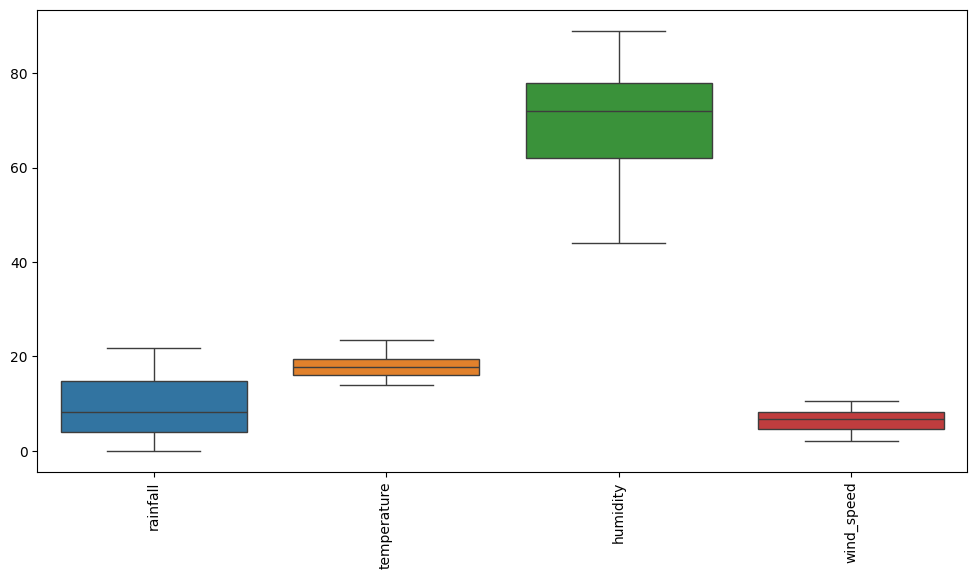

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(data=num_df)
plt.xticks(rotation=90)
plt.show()

# Q19. Identify Outliers (IQR)

In [20]:
Q1 = df["rainfall"].quantile(0.25)
Q3 = df["rainfall"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["rainfall"] < lower) | (df["rainfall"] > upper)]

print(outliers)

Empty DataFrame
Columns: [date, rainfall, temperature, humidity, wind_speed, weather_condition]
Index: []


# Q20. Skewness

In [21]:
print(num_df.skew())

rainfall       0.191925
temperature    0.436075
humidity      -0.564768
wind_speed    -0.207329
dtype: float64


# Q21. KDE plot

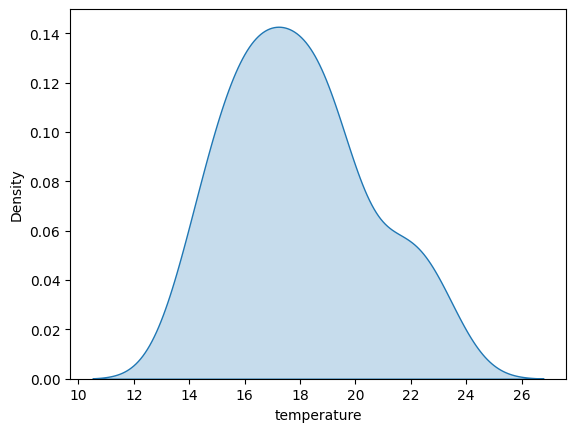

In [22]:
sns.kdeplot(df["temperature"], fill=True)
plt.show()

# Q22. Compare mean and median

In [23]:
print("Mean:", df["rainfall"].mean())
print("Median:", df["rainfall"].median())

Mean: 9.049056603773584
Median: 8.3


# Q23. Right-skewed features

In [24]:
count = (num_df.skew() > 0).sum()

print("Right Skewed Features:", count)

Right Skewed Features: 2


# Q24. Average rainfall grouped by weather condition

In [25]:
df.groupby("weather_condition")["rainfall"].mean()

,rainfall
weather_condition,
Rainy,11.419048
Sunny,0.000000


# Q25. Top 3 highest rainfall

In [26]:
df.nlargest(3, "rainfall")

,date,rainfall,temperature,humidity,wind_speed,weather_condition
29,2022-01-30,21.8,16.4,78.0,7.6,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy
44,2022-02-14,20.5,15.6,81.0,8.2,Rainy


# Q26. Rainfall greater than average

In [27]:
avg = df["rainfall"].mean()

df[df["rainfall"] > avg]

,date,rainfall,temperature,humidity,wind_speed,weather_condition
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy
5,2022-01-06,15.3,16.5,75.0,7.8,Rainy
8,2022-01-09,11.2,17.3,73.0,6.1,Rainy
9,2022-01-10,18.6,15.8,79.0,8.9,Rainy
10,2022-01-11,9.5,16.2,72.0,5.7,Rainy
14,2022-01-15,14.9,15.1,81.0,8.7,Rainy
15,2022-01-16,19.2,16.8,77.0,7.2,Rainy
18,2022-01-19,10.8,17.6,75.0,6.7,Rainy
19,2022-01-20,16.3,14.5,84.0,9.1,Rainy


# Q27. Compare average temperature

In [28]:
avg = df["rainfall"].mean()

high = df[df["rainfall"] > avg]["temperature"].mean()

low = df[df["rainfall"] <= avg]["temperature"].mean()

print("High Rainfall:", high)
print("Low Rainfall:", low)

High Rainfall: 16.253846153846155
Low Rainfall: 19.585185185185182


# Q28. Create High Rainfall column

In [29]:
avg = df["rainfall"].mean()

df["high_rainfall"] = (df["rainfall"] > avg).astype(int)

df.head()

,date,rainfall,temperature,humidity,wind_speed,weather_condition,high_rainfall
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy,1
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy,0
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny,0
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy,0
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy,1


# Q29. Count High Rainfall records

In [30]:
df["high_rainfall"].value_counts()

,count
high_rainfall,
0,28
1,26


# Q30. Correlation only for High Rainfall

In [31]:
df[df["high_rainfall"]==1].corr(numeric_only=True)

,rainfall,temperature,humidity,wind_speed,high_rainfall
rainfall,1.000000,-0.345569,0.409248,0.324545,NaN
temperature,-0.345569,1.000000,-0.943597,-0.916880,NaN
humidity,0.409248,-0.943597,1.000000,0.940413,NaN
wind_speed,0.324545,-0.916880,0.940413,1.000000,NaN
high_rainfall,NaN,NaN,NaN,NaN,NaN


# Q31. Function to detect outliers

In [32]:
def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] < lower) | (data[column] > upper)]

detect_outliers(df, "rainfall")

,date,rainfall,temperature,humidity,wind_speed,weather_condition,high_rainfall


# Q32. Remove Outliers

In [33]:
Q1 = df["rainfall"].quantile(0.25)

Q3 = df["rainfall"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df["rainfall"] >= lower) & (df["rainfall"] <= upper)]

df_clean.head()

,date,rainfall,temperature,humidity,wind_speed,weather_condition,high_rainfall
0,2022-01-01,12.5,15.2,78.0,8.5,Rainy,1
1,2022-01-02,8.2,17.8,65.0,5.2,Rainy,0
2,2022-01-03,0.0,20.1,52.0,3.1,Sunny,0
3,2022-01-04,3.7,18.6,71.0,6.7,Rainy,0
4,2022-01-05,21.1,14.8,82.0,9.3,Rainy,1


## Q33. Min-Max Scaling

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(num_df)

scaled_df = pd.DataFrame(scaled, columns=num_df.columns)

scaled_df.head()

,rainfall,temperature,humidity,wind_speed
0,0.573394,0.136842,0.755556,0.761905
1,0.376147,0.410526,0.466667,0.369048
2,0.000000,0.652632,0.177778,0.119048
3,0.169725,0.494737,0.600000,0.547619
4,0.967890,0.094737,0.844444,0.857143


# Q34. Standardization

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standard = scaler.fit_transform(num_df)

standard_df = pd.DataFrame(standard, columns=num_df.columns)

standard_df.head()

,rainfall,temperature,humidity,wind_speed
0,0.519025,-1.110613,0.738427,0.957999
1,-0.127699,-0.060939,-0.358073,-0.550138
2,-1.360987,0.867619,-1.454573,-1.509862
3,-0.804503,0.262038,0.148004,0.135379
4,1.812474,-1.272101,1.075811,1.323608


# Q35. Pairplot

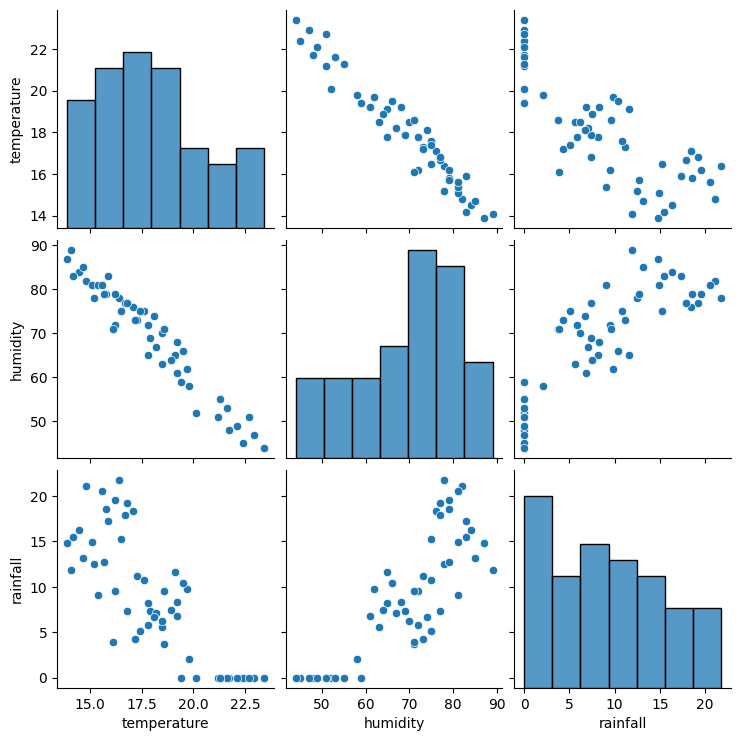

In [36]:
sns.pairplot(df[["temperature","humidity","rainfall"]])
plt.show()

# Q36. Automatic Insights

In [37]:
corr = num_df.corr()["rainfall"]

for feature, value in corr.items():
    if abs(value) > 0.5:
        print(feature, ":", value)

rainfall : 1.0
temperature : -0.7905656348428082
humidity : 0.8213569723603099
wind_speed : 0.7333762456183629


# Q37. Check Target Imbalance

In [38]:
df["high_rainfall"].value_counts()

df["high_rainfall"].value_counts(normalize=True)

,proportion
high_rainfall,
0,0.518519
1,0.481481


# Q38. Distribution Before and After Removing Outliers

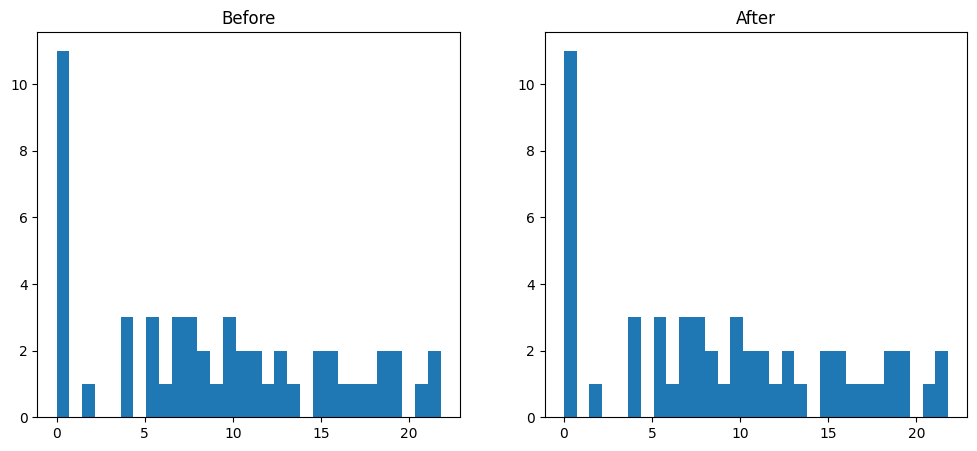

In [39]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df["rainfall"], bins=30)
plt.title("Before")

plt.subplot(1,2,2)
plt.hist(df_clean["rainfall"], bins=30)
plt.title("After")

plt.show()

# Q39. Summary Report

In [40]:
summary = pd.DataFrame({
    "Mean": num_df.mean(),
    "Skewness": num_df.skew(),
    "Outliers": [
        len(detect_outliers(df, col))
        for col in num_df.columns
    ]
})

summary

,Mean,Skewness,Outliers
rainfall,9.049057,0.191925,0
temperature,17.950943,0.436075,0
humidity,69.245283,-0.564768,0
wind_speed,6.403774,-0.207329,0


# Q40. Reusable Full EDA Function

EDA Function Created Successfully
Shape
(54, 7)
Data Types
date                  object
rainfall             float64
temperature          float64
humidity             float64
wind_speed           float64
weather_condition     object
high_rainfall          int64
dtype: object
Missing Values
date                 0
rainfall             1
temperature          1
humidity             1
wind_speed           1
weather_condition    1
high_rainfall        0
dtype: int64
Statistics
        rainfall  temperature   humidity  wind_speed  high_rainfall
count  53.000000    53.000000  53.000000   53.000000      54.000000
mean    9.049057    17.950943  69.245283    6.403774       0.481481
std     6.712521     2.500663  11.969361    2.209069       0.504349
min     0.000000    13.900000  44.000000    2.100000       0.000000
25%     3.900000    16.100000  62.000000    4.700000       0.000000
50%     8.300000    17.800000  72.000000    6.700000       0.000000
75%    14.800000    19.400000  78.000000    8.30

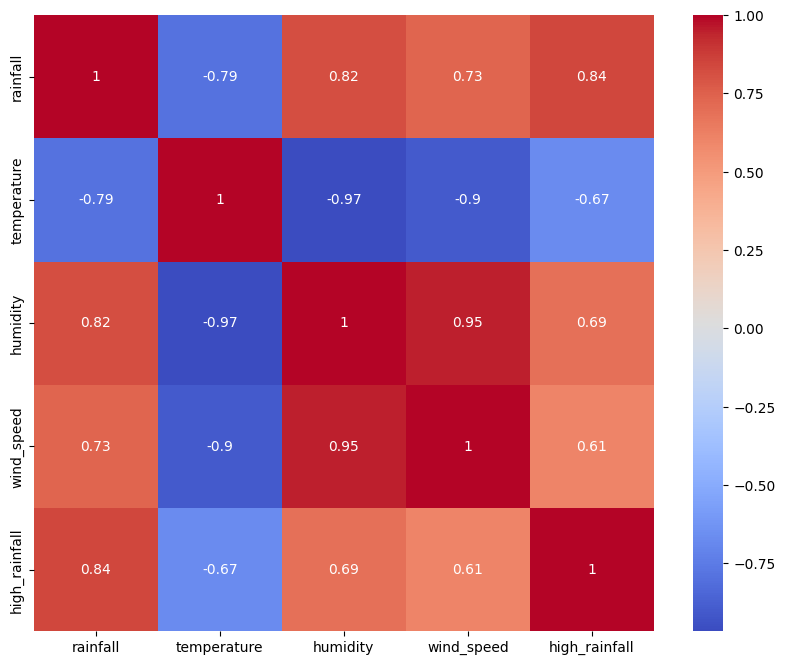

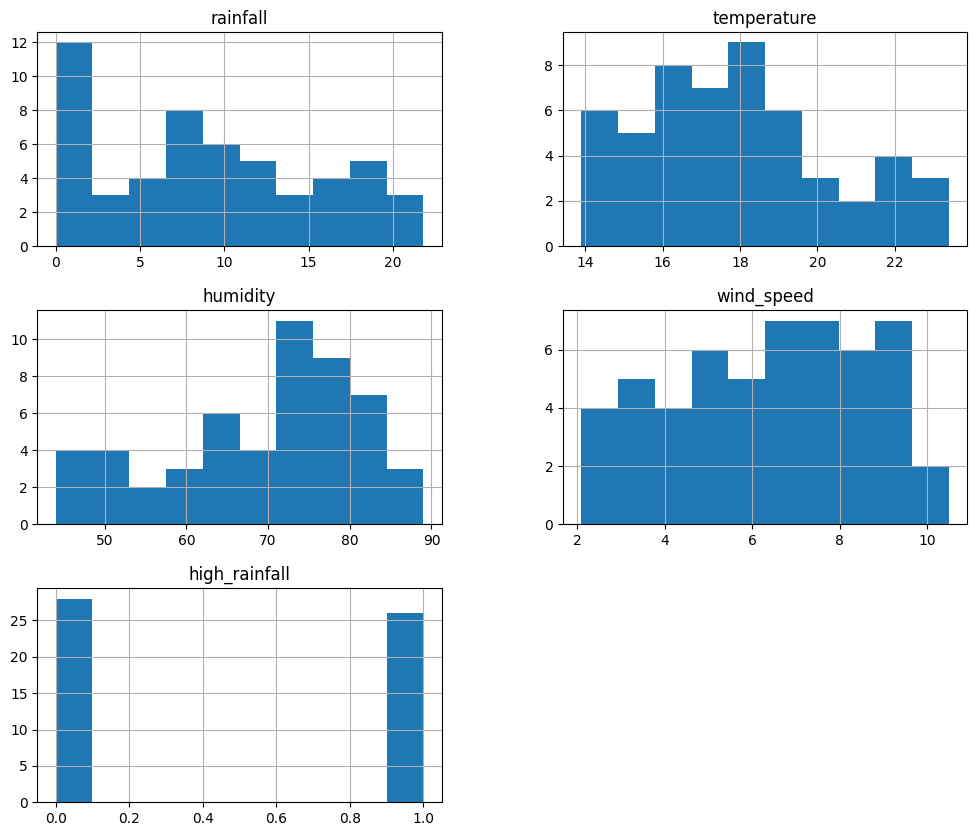

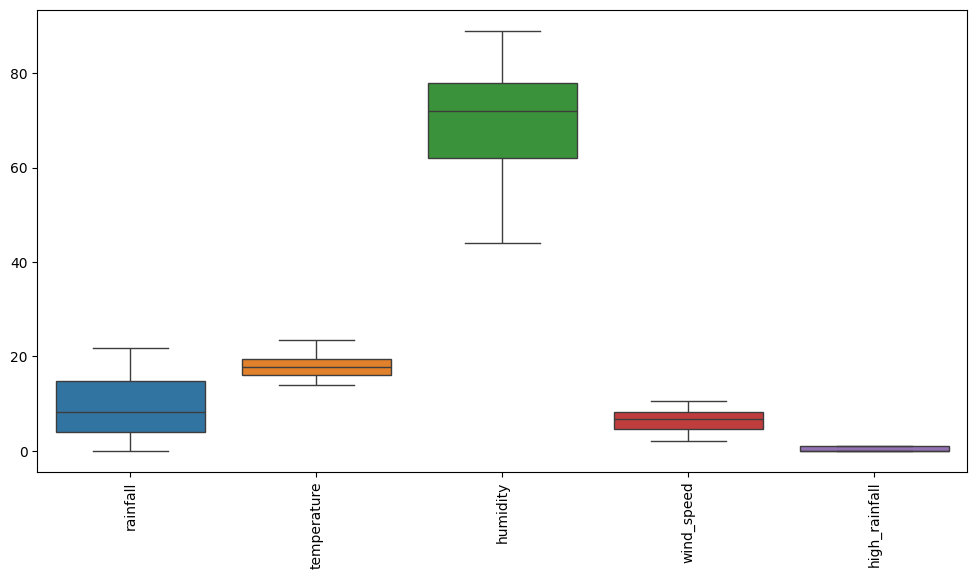

In [41]:
def full_eda(data):

    print("="*50)
    print("Shape")
    print(data.shape)

    print("="*50)
    print("Data Types")
    print(data.dtypes)

    print("="*50)
    print("Missing Values")
    print(data.isnull().sum())

    print("="*50)
    print("Statistics")
    print(data.describe())

    numeric = data.select_dtypes(include=np.number)

    print("="*50)
    print("Correlation Matrix")
    print(numeric.corr())

    plt.figure(figsize=(10,8))
    sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")
    plt.show()

    numeric.hist(figsize=(12,10))
    plt.show()

    plt.figure(figsize=(12,6))
    sns.boxplot(data=numeric)
    plt.xticks(rotation=90)
    plt.show()

print("EDA Function Created Successfully")

# Call Function
full_eda(df)